# Performances across test sets
This Notebook shows the different performance metrics according to different scenarios.

## C-index

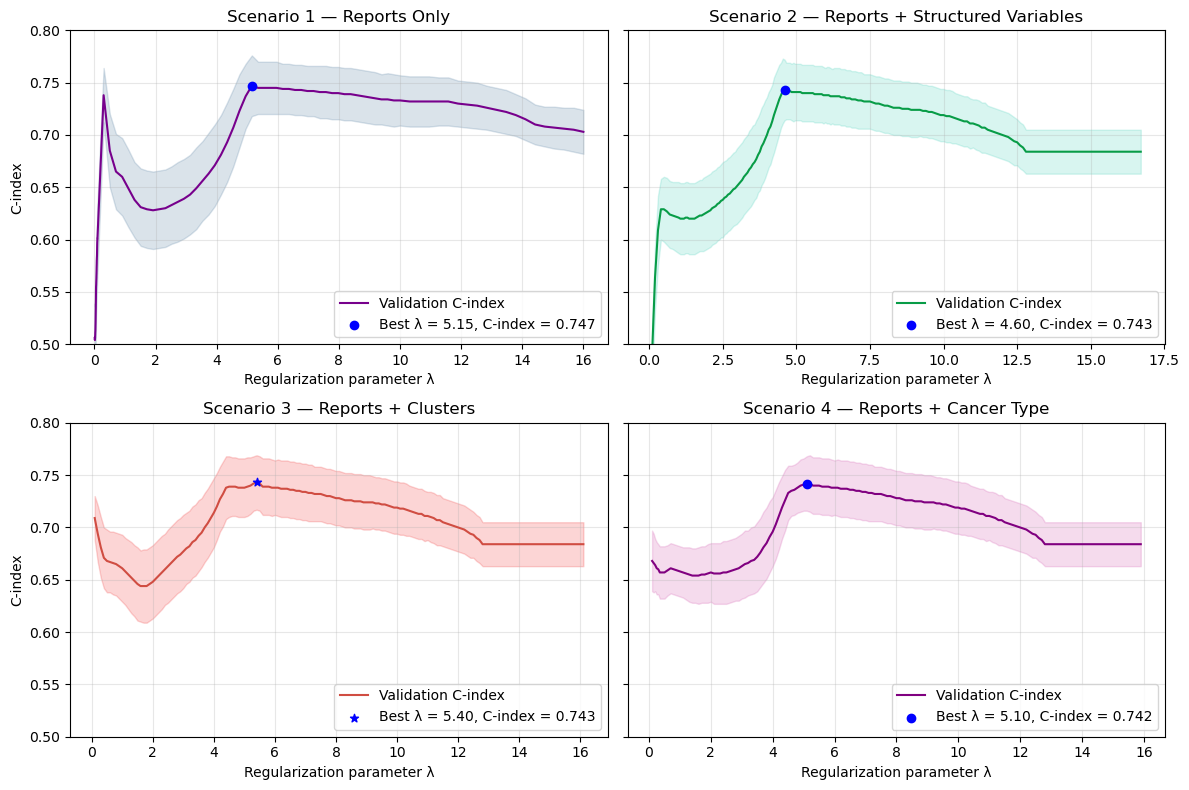

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Load and prepare data
# ---------------------------------------------------------

# Scenario 1 — Reports Only
df_results_RO = (
    pd.read_csv("df_results_lambda_RO_C-index.csv")
    .sort_values("lambda")
    .reset_index(drop=True)
)

# Scenario 2 — Reports + Structured Variables
df_results_RS = (
    pd.read_csv("df_results_lambda_RS_C-index.csv")
    .sort_values("lambda")
    .reset_index(drop=True)
)

# Scenario 3 — Reports + Clusters
df_results_RC = (
    pd.read_csv("df_results_lambda_Cluster_C-index.csv")
    .sort_values("lambda")
    .reset_index(drop=True)
)

# Scenario 4 — Reports + Cancer Type
df_results_cancer = (
    pd.read_csv("df_results_lambda_Known-Cancer_C-index.csv")
    .sort_values("lambda")
    .reset_index(drop=True)
)
# ---------------------------------------------------------
# Extract values
# ---------------------------------------------------------

l_ro = df_results_RO["lambda"].values
m_ro = df_results_RO["Mean C-index Test"].values
s_ro = df_results_RO["C-index Test sd"].values

l_rs = df_results_RS["lambda"].values
m_rs = df_results_RS["Mean C-index Test"].values
s_rs = df_results_RS["C-index Test sd"].values

l_rc = df_results_RC["lambda"].values
m_rc = df_results_RC["Mean C-index Test"].values
s_rc = df_results_RC["C-index Test sd"].values

l_ca = df_results_cancer["lambda"].values
m_ca = df_results_cancer["Mean C-index Test"].values
s_ca = df_results_cancer["C-index Test sd"].values

# ---------------------------------------------------------
# Compute argmax points
# ---------------------------------------------------------

idx_ro = np.argmax(m_ro)
idx_rs = np.argmax(m_rs)
idx_rc = np.argmax(m_rc)
idx_ca = np.argmax(m_ca)

lambda_ro_max, c_ro_max = l_ro[idx_ro], m_ro[idx_ro]
lambda_rs_max, c_rs_max = l_rs[idx_rs], m_rs[idx_rs]
lambda_rc_max, c_rc_max = l_rc[idx_rc], m_rc[idx_rc]
lambda_ca_max, c_ca_max = l_ca[idx_ca], m_ca[idx_ca]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

# Scenario 1
axes[0,0].plot(l_ro, m_ro, color="#77008C", label="Validation C-index")
axes[0,0].fill_between(l_ro, m_ro - s_ro, m_ro + s_ro, color="#48759A", alpha=0.2)
axes[0,0].scatter(lambda_ro_max, c_ro_max, color="blue", zorder=5,
                  label=f"Best λ = {lambda_ro_max:.2f}, C-index = {c_ro_max:.3f}")
axes[0,0].set_title("Scenario 1 — Reports Only")
axes[0,0].set_xlabel("Regularization parameter λ")
axes[0,0].set_ylabel("C-index")
axes[0,0].set_ylim(0.5, 0.8)
axes[0,0].grid(alpha=0.3)
axes[0,0].legend(loc="lower right")

# Scenario 2
axes[0,1].plot(l_rs, m_rs, color="#089C47", label="Validation C-index")
axes[0,1].fill_between(l_rs, m_rs - s_rs, m_rs + s_rs, color="#3DCEB7", alpha=0.2)
axes[0,1].scatter(lambda_rs_max, c_rs_max, color="blue", zorder=5,
                  label=f"Best λ = {lambda_rs_max:.2f}, C-index = {c_rs_max:.3f}")
axes[0,1].set_title("Scenario 2 — Reports + Structured Variables")
axes[0,1].set_xlabel("Regularization parameter λ")
axes[0,1].set_ylim(0.5, 0.8)
axes[0,1].grid(alpha=0.3)
axes[0,1].legend(loc="lower right")

# Scenario 3
axes[1,0].plot(l_rc, m_rc, color="#D04D42", label="Validation C-index")
axes[1,0].fill_between(l_rc, m_rc - s_rc, m_rc + s_rc, color="#F02D2D", alpha=0.2)
axes[1,0].scatter(lambda_rc_max, c_rc_max, color="blue", marker="*", zorder=5,
                  label=f"Best λ = {lambda_rc_max:.2f}, C-index = {c_rc_max:.3f}")
axes[1,0].set_title("Scenario 3 — Reports + Clusters")
axes[1,0].set_xlabel("Regularization parameter λ")
axes[1,0].set_ylabel("C-index")
axes[1,0].set_ylim(0.5, 0.8)
axes[1,0].grid(alpha=0.3)
axes[1,0].legend(loc="lower right")

# Scenario 4
axes[1,1].plot(l_ca, m_ca, color="purple", label="Validation C-index")
axes[1,1].fill_between(l_ca, m_ca - s_ca, m_ca + s_ca, color="#D04DA9", alpha=0.2)
axes[1,1].scatter(lambda_ca_max, c_ca_max, color="blue", zorder=5,
                  label=f"Best λ = {lambda_ca_max:.2f}, C-index = {c_ca_max:.3f}")
axes[1,1].set_title("Scenario 4 — Reports + Cancer Type")
axes[1,1].set_xlabel("Regularization parameter λ")
axes[1,1].set_ylim(0.5, 0.8)
axes[1,1].grid(alpha=0.3)
axes[1,1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## Integrated Brier Score at 3years

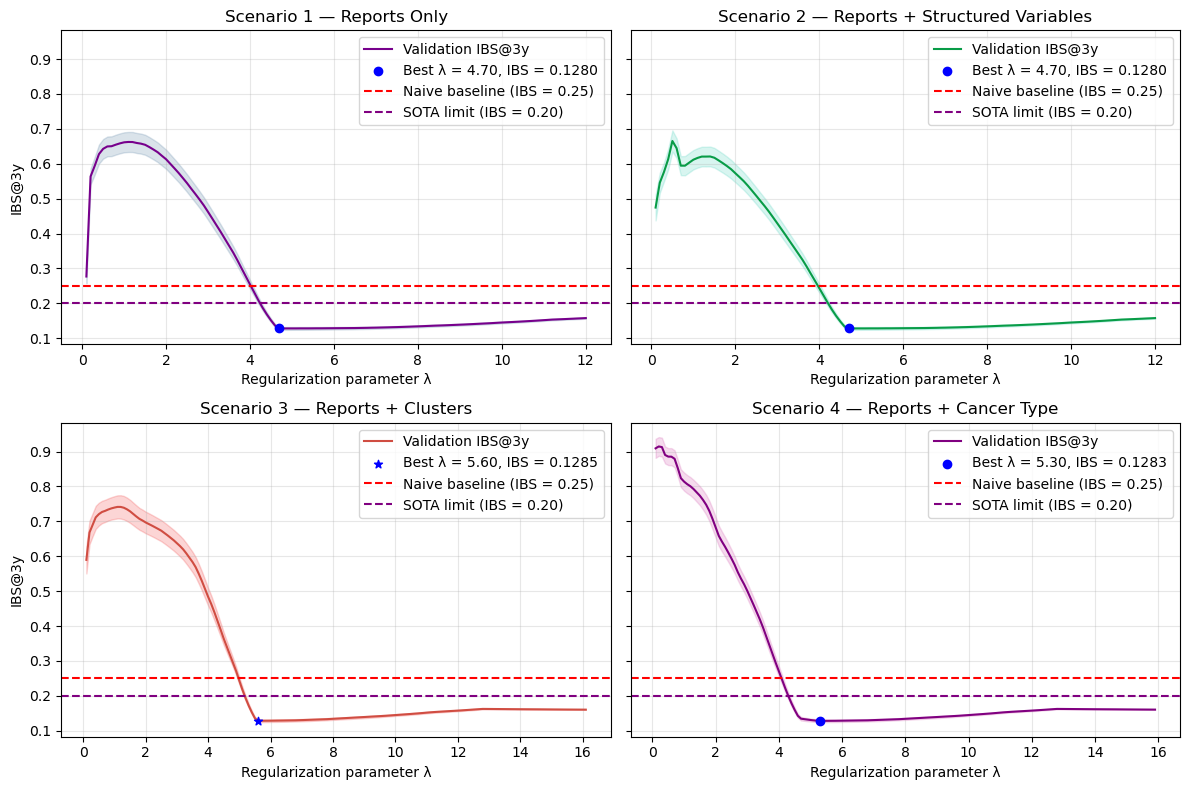

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Helper to extract CI bounds
# ---------------------------------------------------------

def parse_ci(series):
    lower = series.str.extract(r"\[(.*?),")[0].astype(float)
    upper = series.str.extract(r",(.*?)\]")[0].astype(float)
    return lower.values, upper.values


# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------

df_results_RO = (
    pd.read_csv("./df_results_lambda_RO_BS-CI.csv")
    .sort_values("lambda")
    .reset_index(drop=True)
)

df_results_RS = (
    pd.read_csv("./df_results_lambda_both_BS-CI.csv")
    .sort_values("lambda")
    .reset_index(drop=True)
)

df_results_RC = (
    pd.read_csv("./df_results_lambda_cluster_BS-CI.csv")
    .sort_values("lambda")
    .reset_index(drop=True)
)

df_results_CA = (
    pd.read_csv("./df_results_lambda_RO_cancer_BS-CI.csv")
    .sort_values("lambda")
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Extract values
# ---------------------------------------------------------

l_ro = df_results_RO["lambda"].values
m_ro = df_results_RO["IBS@3y"].values
lo_ro, hi_ro = parse_ci(df_results_RO["IBS@3y CI95%"])

l_rs = df_results_RS["lambda"].values
m_rs = df_results_RS["IBS@3y"].values
lo_rs, hi_rs = parse_ci(df_results_RS["IBS@3y CI95%"])

l_rc = df_results_RC["lambda"].values
m_rc = df_results_RC["IBS@3y"].values
lo_rc, hi_rc = parse_ci(df_results_RC["IBS@3y CI95%"])

l_ca = df_results_CA["lambda"].values
m_ca = df_results_CA["IBS@3y"].values
lo_ca, hi_ca = parse_ci(df_results_CA["IBS@3y CI95%"])


# ---------------------------------------------------------
# Compute argmin points
# ---------------------------------------------------------

idx_ro = np.argmin(m_ro)
idx_rs = np.argmin(m_rs)
idx_rc = np.argmin(m_rc)
idx_ca = np.argmin(m_ca)

lambda_ro_best, ibs_ro_best = l_ro[idx_ro], m_ro[idx_ro]
lambda_rs_best, ibs_rs_best = l_rs[idx_rs], m_rs[idx_rs]
lambda_rc_best, ibs_rc_best = l_rc[idx_rc], m_rc[idx_rc]
lambda_ca_best, ibs_ca_best = l_ca[idx_ca], m_ca[idx_ca]


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

baseline = 0.25
sota = 0.20

def add_reference_lines(ax):
    ax.axhline(baseline, linestyle="--", color="red", linewidth=1.5,
               label="Naive baseline (IBS = 0.25)")
    ax.axhline(sota, linestyle="--", color="purple", linewidth=1.5,
               label="SOTA limit (IBS = 0.20)")
    #ax.set_ylim(0, 0.27)


# Scenario 1
axes[0,0].plot(l_ro, m_ro, color="#77008C", label="Validation IBS@3y")
axes[0,0].fill_between(l_ro, lo_ro, hi_ro, color="#48759A", alpha=0.2)
axes[0,0].scatter(lambda_ro_best, ibs_ro_best, color="blue", zorder=5,
                  label=f"Best λ = {lambda_ro_best:.2f}, IBS = {ibs_ro_best:.4f}")
add_reference_lines(axes[0,0])
axes[0,0].set_title("Scenario 1 — Reports Only")
axes[0,0].set_xlabel("Regularization parameter λ")
axes[0,0].set_ylabel("IBS@3y")
axes[0,0].grid(alpha=0.3)
axes[0,0].legend(loc="upper right")


# Scenario 2
axes[0,1].plot(l_rs, m_rs, color="#089C47", label="Validation IBS@3y")
axes[0,1].fill_between(l_rs, lo_rs, hi_rs, color="#3DCEB7", alpha=0.2)
axes[0,1].scatter(lambda_rs_best, ibs_rs_best, color="blue", zorder=5,
                  label=f"Best λ = {lambda_rs_best:.2f}, IBS = {ibs_rs_best:.4f}")
add_reference_lines(axes[0,1])
axes[0,1].set_title("Scenario 2 — Reports + Structured Variables")
axes[0,1].set_xlabel("Regularization parameter λ")
axes[0,1].grid(alpha=0.3)
axes[0,1].legend(loc="upper right")


# Scenario 3
axes[1,0].plot(l_rc, m_rc, color="#D04D42", label="Validation IBS@3y")
axes[1,0].fill_between(l_rc, lo_rc, hi_rc, color="#F02D2D", alpha=0.2)
axes[1,0].scatter(lambda_rc_best, ibs_rc_best, color="blue", marker="*", zorder=5,
                  label=f"Best λ = {lambda_rc_best:.2f}, IBS = {ibs_rc_best:.4f}")
add_reference_lines(axes[1,0])
axes[1,0].set_title("Scenario 3 — Reports + Clusters")
axes[1,0].set_xlabel("Regularization parameter λ")
axes[1,0].set_ylabel("IBS@3y")
axes[1,0].grid(alpha=0.3)
axes[1,0].legend(loc="upper right")


# Scenario 4
axes[1,1].plot(l_ca, m_ca, color="purple", label="Validation IBS@3y")
axes[1,1].fill_between(l_ca, lo_ca, hi_ca, color="#D04DA9", alpha=0.2)
axes[1,1].scatter(lambda_ca_best, ibs_ca_best, color="blue", zorder=5,
                  label=f"Best λ = {lambda_ca_best:.2f}, IBS = {ibs_ca_best:.4f}")
add_reference_lines(axes[1,1])
axes[1,1].set_title("Scenario 4 — Reports + Cancer Type")
axes[1,1].set_xlabel("Regularization parameter λ")
axes[1,1].grid(alpha=0.3)
axes[1,1].legend(loc="upper right")


plt.tight_layout()
plt.show()